In [1]:
# ============================================
# LIBRERÍAS REQUERIDAS
# ============================================
import pandas as pd
import matplotlib.pyplot as plt
import glob
import random

In [2]:
# ============================================
# 1. CARGAR Y SELECCIONAR MUESTRA DE DATOS
# ============================================
# Establecer seed para reproducibilidad
random.seed(3)

# Buscar archivos CSV de eventos
nov_files = glob.glob("./data/online+retail/split/2019-Nov_part_*.csv")
oct_files = glob.glob("./data/online+retail/split/2019-Oct_part_*.csv")

# Seleccionar 10 archivos aleatorios de cada mes
nov_sample = random.sample(nov_files, 10)
oct_sample = random.sample(oct_files, 10)

print("\n=== DATOS CARGADOS ===\n")
print(f"Archivos seleccionados (Noviembre): {len(nov_sample)}")
print(f"Archivos seleccionados (Octubre): {len(oct_sample)}")


=== DATOS CARGADOS ===

Archivos seleccionados (Noviembre): 10
Archivos seleccionados (Octubre): 10


In [3]:
# ============================================
# 2. CONSOLIDAR DATOS
# ============================================
# Combinar archivos en un único dataframe
files = nov_sample + oct_sample

dfs = []
for f in files:
    df = pd.read_csv(f)
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

print(f"Tamaño dataset consolidado: {data.shape[0]:,} registros x {data.shape[1]} columnas")

Tamaño dataset consolidado: 20,000,000 registros x 9 columnas


In [4]:
# ============================================
# 3. PREPARACIÓN Y VARIABLES TEMPORALES
# ============================================
# Convertir timestamp a datetime
data["event_time"] = pd.to_datetime(data["event_time"])

# Crear variables útiles para análisis temporal
data["hour"] = data["event_time"].dt.hour  # hora del evento
data["date"] = data["event_time"].dt.date  # fecha del evento

In [5]:
# ============================================
# 4. EXPLORACIÓN INICIAL DE LOS DATOS
# ============================================
print("\n=== PRIMERAS FILAS DEL DATASET ===\n")
print(data.head())


=== PRIMERAS FILAS DEL DATASET ===

                 event_time event_type  product_id          category_id  \
0 2019-11-16 11:39:52+00:00       view     3600661  2053013563810775923   
1 2019-11-16 11:39:52+00:00       view    12703432  2053013553559896355   
2 2019-11-16 11:39:52+00:00       view     1003312  2053013555631882655   
3 2019-11-16 11:39:52+00:00       view    12400401  2053013556252639687   
4 2019-11-16 11:39:52+00:00       view    30000218  2127425436764865054   

                category_code     brand   price    user_id  \
0   appliances.kitchen.washer   samsung  308.86  530807291   
1                         NaN  michelin   72.07  532960822   
2      electronics.smartphone     apple  745.70  514321345   
3    construction.tools.drill     crown   84.94  530757755   
4  construction.tools.welding  magnetta  249.68  569561503   

                           user_session  hour        date  
0  b590568c-b618-4a0b-a933-9492b99db791    11  2019-11-16  
1  1801cefc-9897-40

In [6]:
# Información de estructura y tipos de datos
print("\n=== ESTRUCTURA DEL DATASET ===\n")
print(data.info())


=== ESTRUCTURA DEL DATASET ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000000 entries, 0 to 19999999
Data columns (total 11 columns):
 #   Column         Dtype              
---  ------         -----              
 0   event_time     datetime64[ns, UTC]
 1   event_type     object             
 2   product_id     int64              
 3   category_id    int64              
 4   category_code  object             
 5   brand          object             
 6   price          float64            
 7   user_id        int64              
 8   user_session   object             
 9   hour           int32              
 10  date           object             
dtypes: datetime64[ns, UTC](1), float64(1), int32(1), int64(3), object(5)
memory usage: 1.6+ GB
None


In [7]:
# Análisis de valores nulos
print("\n=== PROPORCIÓN DE VALORES NULOS ===\n")
print(data.isnull().sum() / data.shape[0])


=== PROPORCIÓN DE VALORES NULOS ===

event_time       0.000000e+00
event_type       0.000000e+00
product_id       0.000000e+00
category_id      0.000000e+00
category_code    3.192687e-01
brand            1.384192e-01
price            0.000000e+00
user_id          0.000000e+00
user_session     1.000000e-07
hour             0.000000e+00
date             0.000000e+00
dtype: float64


In [8]:
# Estadísticas descriptivas numéricas
print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===\n")
print(data.describe())


=== ESTADÍSTICAS DESCRIPTIVAS ===

         product_id   category_id         price       user_id          hour
count  2.000000e+07  2.000000e+07  2.000000e+07  2.000000e+07  2.000000e+07
mean   1.148433e+07  2.057606e+18  2.912650e+02  5.363775e+08  1.151373e+01
std    1.506101e+07  1.923351e+16  3.576545e+02  2.116606e+07  5.005802e+00
min    1.000978e+06  2.053014e+18  0.000000e+00  3.386938e+07  0.000000e+00
25%    1.005221e+06  2.053014e+18  6.690000e+01  5.162509e+08  8.000000e+00
50%    5.000801e+06  2.053014e+18  1.647400e+02  5.326053e+08  1.200000e+01
75%    1.660021e+07  2.053014e+18  3.601100e+02  5.556330e+08  1.500000e+01
max    1.000269e+08  2.187708e+18  2.574070e+03  5.786382e+08  2.300000e+01


In [9]:
# ============================================
# 5. ANÁLISIS DE TIPOS DE EVENTOS
# ============================================
# Distribución de frecuencias de eventos
event_counts = data["event_type"].value_counts()

print("\n=== DISTRIBUCIÓN DE TIPOS DE EVENTO ===\n")
print(event_counts)
print(f"\n=== PROPORCIÓN (%) ===\n")
print((data["event_type"].value_counts(normalize=True) * 100).round(2))


=== DISTRIBUCIÓN DE TIPOS DE EVENTO ===

event_type
view        19009570
cart          640617
purchase      349813
Name: count, dtype: int64

=== PROPORCIÓN (%) ===

event_type
view        95.05
cart         3.20
purchase     1.75
Name: proportion, dtype: float64


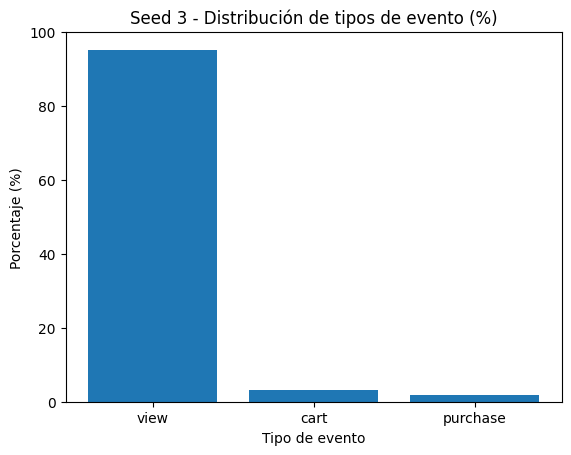

In [10]:
# Visualización: Distribución de tipos de evento
plt.figure()
porcentajes = (event_counts / event_counts.sum() * 100)
plt.bar(porcentajes.index, porcentajes.values)
plt.title("Seed 3 - Distribución de tipos de evento (%)")
plt.xlabel("Tipo de evento")
plt.ylabel("Porcentaje (%)")
plt.ylim(0, 100)
plt.show()

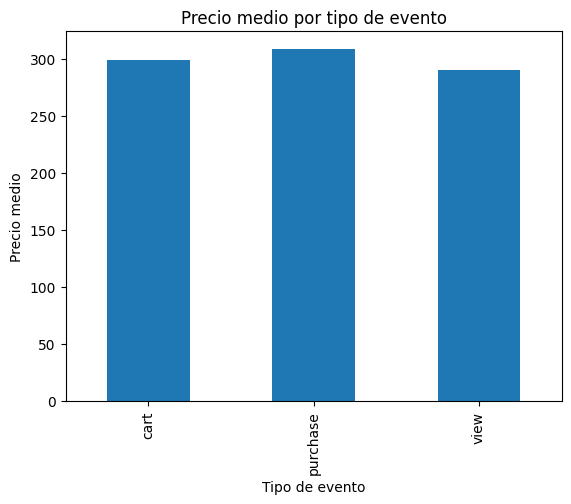

In [11]:
# Análisis de precios por tipo de evento
price_event = data.groupby("event_type")["price"].mean()

# Visualización: Precio promedio por tipo de evento
plt.figure()
price_event.plot(kind="bar")
plt.title("Precio medio por tipo de evento")
plt.xlabel("Tipo de evento")
plt.ylabel("Precio medio")
plt.show()

In [12]:
# ============================================
# 6. ANÁLISIS DE EVENTOS POR USUARIO
# ============================================
# Contar eventos por usuario
events_user = data.groupby("user_id").size()
distribution = events_user.value_counts().sort_index()

print("\n=== DISTRIBUCIÓN DE EVENTOS POR USUARIO (Primeras 20) ===\n")
print(distribution.head(20))


=== DISTRIBUCIÓN DE EVENTOS POR USUARIO (Primeras 20) ===

1     495789
2     264993
3     192729
4     144042
5     109949
6      89634
7      74344
8      63697
9      54385
10     47256
11     41685
12     36716
13     33022
14     29188
15     26455
16     23566
17     21560
18     19567
19     17854
20     16309
Name: count, dtype: int64


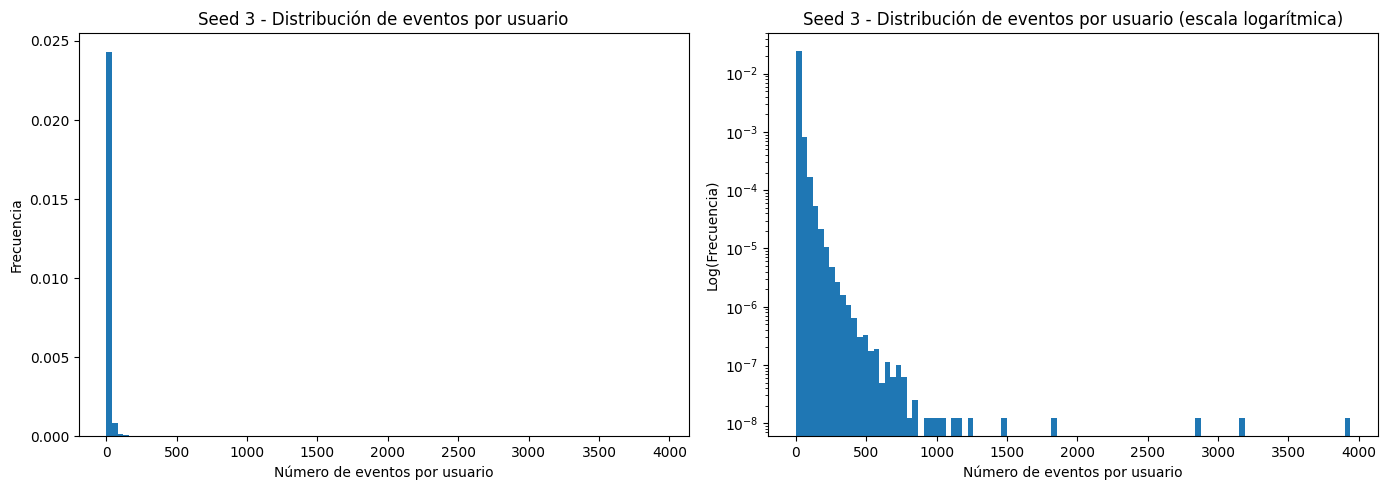

In [15]:
# Visualización: Histograma de eventos por usuario
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Primer gráfico - escala lineal
ax1.hist(events_user, bins=100, density=True)
ax1.set_title("Seed 3 - Distribución de eventos por usuario")
ax1.set_xlabel("Número de eventos por usuario")
ax1.set_ylabel("Frecuencia")

# Segundo gráfico - escala logarítmica
ax2.hist(events_user, bins=100, density=True, log=True)
ax2.set_title("Seed 3 - Distribución de eventos por usuario (escala logarítmica)")
ax2.set_xlabel("Número de eventos por usuario")
ax2.set_ylabel("Log(Frecuencia)")

plt.tight_layout()
plt.show()

In [14]:
# ============================================
# 7. ANÁLISIS DE MARCAS
# ============================================
# Top 10 marcas por frecuencia
print("\n=== TOP 10 MARCAS ===\n")
print(data["brand"].value_counts().head(10))


=== TOP 10 MARCAS ===

brand
samsung    2444902
apple      1909862
xiaomi     1439375
huawei      484908
lucente     320354
lg          290919
bosch       267823
oppo        234726
sony        232089
acer        205620
Name: count, dtype: int64


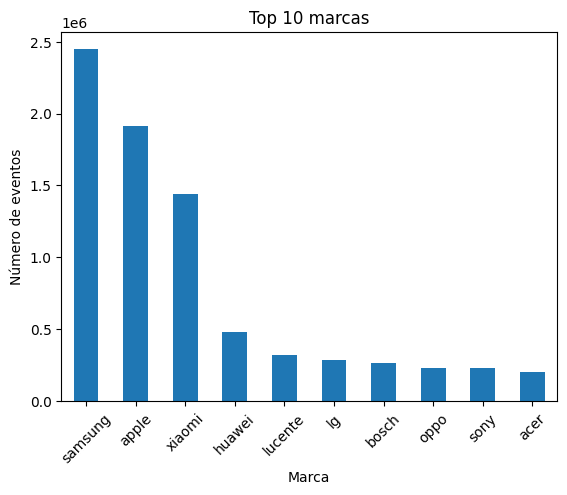

In [15]:
# Visualización: Top 10 marcas
top_brands = data["brand"].value_counts().head(10)

plt.figure()
top_brands.plot(kind="bar")
plt.title("Top 10 marcas")
plt.xlabel("Marca")
plt.ylabel("Número de eventos")
plt.xticks(rotation=45)
plt.show()

In [16]:
# ============================================
# 8. ANÁLISIS DE CATEGORÍAS
# ============================================
# Top 10 categorías
top_categories = data["category_code"].value_counts().head(10)

print("\n=== TOP 10 CATEGORÍAS ===\n")
print(top_categories)


=== TOP 10 CATEGORÍAS ===

category_code
electronics.smartphone              5212839
electronics.clocks                   631196
computers.notebook                   595279
electronics.video.tv                 579729
electronics.audio.headphone          539869
apparel.shoes                        436287
appliances.kitchen.refrigerators     415516
appliances.kitchen.washer            412990
appliances.environment.vacuum        405300
computers.desktop                    204589
Name: count, dtype: int64


In [17]:
# Análisis de categorías en compras
purchases = data[data["event_type"] == "purchase"]

print("\n=== TOP 10 CATEGORÍAS EN COMPRAS ===\n")
print(purchases["category_code"].value_counts().head(10))


=== TOP 10 CATEGORÍAS EN COMPRAS ===

category_code
electronics.smartphone              153162
electronics.audio.headphone          15284
electronics.video.tv                 11125
electronics.clocks                    8972
appliances.kitchen.washer             7712
computers.notebook                    7508
appliances.environment.vacuum         6525
appliances.kitchen.refrigerators      5249
apparel.shoes                         2487
electronics.tablet                    2481
Name: count, dtype: int64


In [18]:
# ============================================
# 9. ANÁLISIS DE PRECIOS
# ============================================
print("\n=== ESTADÍSTICAS DE PRECIOS ===\n")
print(f"Precio promedio: {data['price'].mean():.2f}")
print(f"Precio máximo: {data['price'].max():.2f}")
print(f"Precio mínimo: {data['price'].min():.2f}")


=== ESTADÍSTICAS DE PRECIOS ===

Precio promedio: 291.26
Precio máximo: 2574.07
Precio mínimo: 0.00


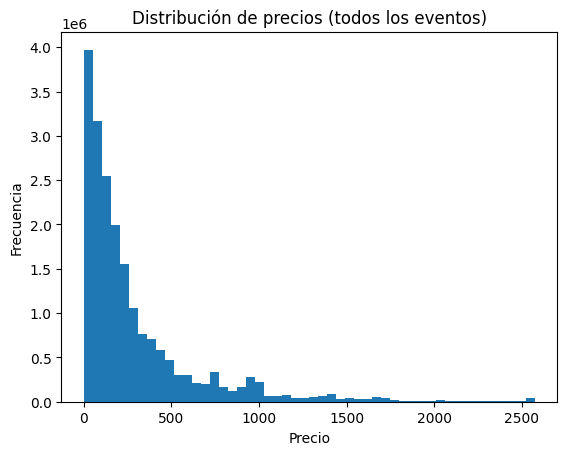

In [19]:
# Visualización: Distribución de precios
plt.figure()
plt.hist(data["price"].dropna(), bins=50)
plt.title("Distribución de precios (todos los eventos)")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()

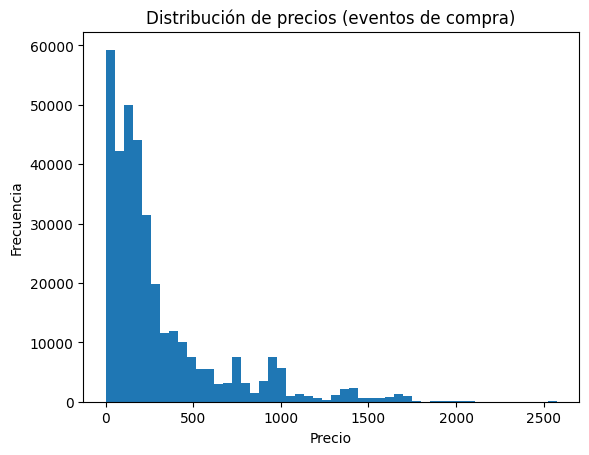

In [20]:
# Visualización: Distribución de precios en compras
purchase_prices = purchases["price"]

plt.figure()
plt.hist(purchase_prices.dropna(), bins=50)
plt.title("Distribución de precios (eventos de compra)")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()

In [21]:
# ============================================
# 10. ANÁLISIS DE COBERTURA DE USUARIOS Y SESIONES
# ============================================
print("\n=== COBERTURA DE USUARIOS Y SESIONES ===\n")
print(f"Usuarios únicos: {data['user_id'].nunique():,}")
print(f"Sesiones únicas: {data['user_session'].nunique():,}")


=== COBERTURA DE USUARIOS Y SESIONES ===

Usuarios únicos: 2,050,141
Sesiones únicas: 4,373,658


In [22]:
# Información adicional de sesiones
print(f"Promedio de eventos por sesión: {len(data) / data['user_session'].nunique():.2f}")

Promedio de eventos por sesión: 4.57


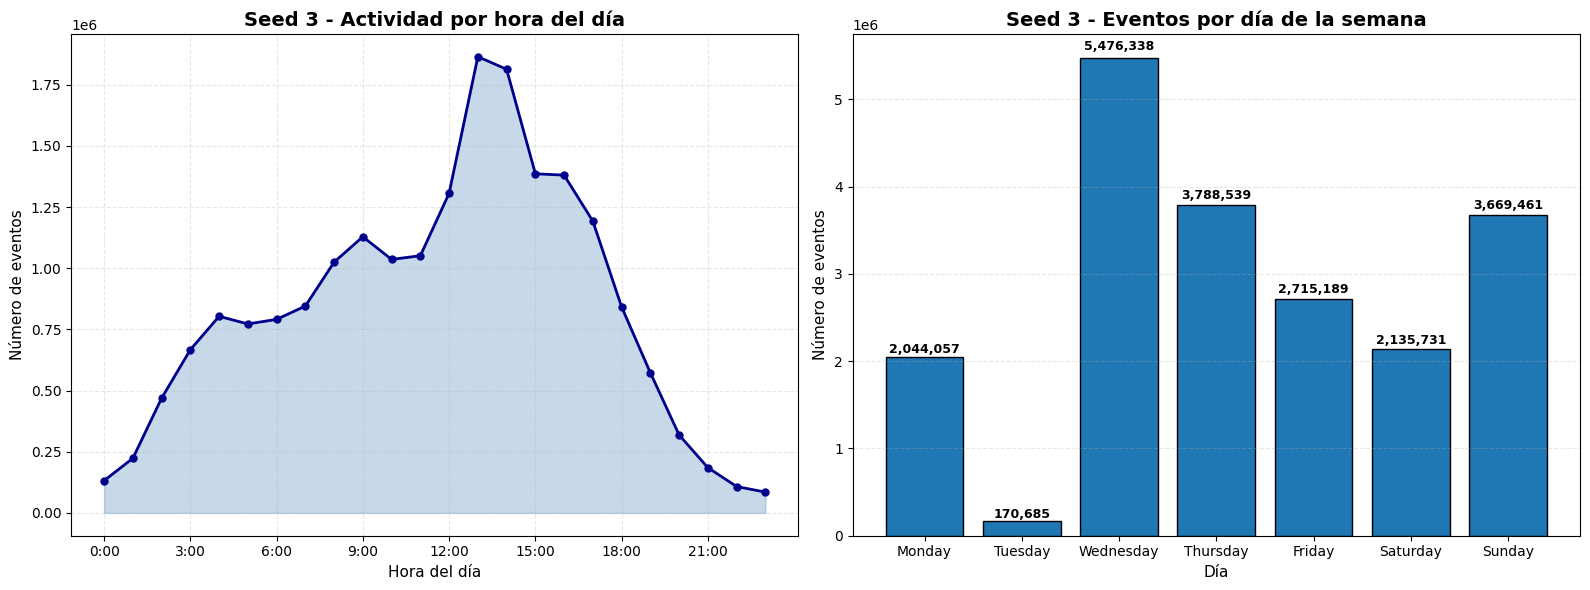


=== ESTADÍSTICAS DE ACTIVIDAD ===

Hora pico: 13 (1,864,944 eventos)
Hora valle: 23 (85,030 eventos)
Día más activo: Wednesday (5,476,338 eventos)
Día menos activo: Tuesday (170,685 eventos)


In [16]:
# ============================================
# 11. ANÁLISIS TEMPORAL
# ============================================
# Datos por hora
data["hour"] = data["event_time"].dt.hour
events_hour = data.groupby("hour").size()

# Datos por día de la semana
data["weekday"] = data["event_time"].dt.day_name()
weekday_events = data.groupby("weekday").size()
weekday_events = weekday_events.reindex([
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
])

# ============================================
# GRÁFICOS LADO A LADO - VERSIÓN MEJORADA
# ============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Actividad por hora (área rellena)
ax1.fill_between(events_hour.index, events_hour.values, alpha=0.3, color='steelblue')
ax1.plot(events_hour.index, events_hour.values, marker='o', linewidth=2, markersize=5, color='darkblue')
ax1.set_title("Seed 3 - Actividad por hora del día", fontsize=14, fontweight='bold')
ax1.set_xlabel("Hora del día", fontsize=11)
ax1.set_ylabel("Número de eventos", fontsize=11)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xticks(range(0, 24, 3))  # Mostrar cada 3 horas: 0, 3, 6, ..., 21
ax1.set_xticklabels([f"{h}:00" for h in range(0, 24, 3)])

# Gráfico 2: Eventos por día de la semana
bars = ax2.bar(weekday_events.index, weekday_events.values,  edgecolor='black', linewidth=1)
ax2.set_title("Seed 3 - Eventos por día de la semana", fontsize=14, fontweight='bold')
ax2.set_xlabel("Día", fontsize=11)
ax2.set_ylabel("Número de eventos", fontsize=11)
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')

# Añadir etiquetas de valor en las barras
for bar, value in zip(bars, weekday_events.values):
    ax2.text(bar.get_x() + bar.get_width()/2., value + value*0.01,
             f'{int(value):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# ESTADÍSTICAS ADICIONALES (opcional)
# ============================================
print("\n=== ESTADÍSTICAS DE ACTIVIDAD ===\n")
print(f"Hora pico: {events_hour.idxmax()} ({events_hour.max():,} eventos)")
print(f"Hora valle: {events_hour.idxmin()} ({events_hour.min():,} eventos)")
print(f"Día más activo: {weekday_events.idxmax()} ({weekday_events.max():,} eventos)")
print(f"Día menos activo: {weekday_events.idxmin()} ({weekday_events.min():,} eventos)")